In [1]:
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# infpath = '/mnt/data/Max/repos/reverlor/param_selection/test_repeat_detection/workdir_minimap2/find_repeats_results/merged.tsv'
# infpath = '/mnt/data/Max/repos/reverlor/param_selection/test_repeat_detection/workdir_repeatscout/find_repeats_results/merged.tsv'
infpath = '/mnt/data/Max/repos/reverlor/param_selection/test_repeat_detection/workdir_phraider/find_repeats_results/merged.tsv'

In [3]:
df = pl.read_csv(infpath, separator='\t')

In [4]:
df = df.with_columns(
    (
        pl.col('repeat_len').cast(pl.String) \
        + '_' \
        + pl.col('repeat_idx').cast(pl.String) \
        + '_' \
        + pl.col('rate').cast(pl.String) \
    ).alias('repeat_id')
)

In [5]:
# For phRAIDER, since it doesn't search for rc-repeats

df = df.filter(
    ~(
        (pl.col('value_type') == 'true') & (pl.col('strand') == '-')
    )
)

In [6]:
df.height

89125

In [7]:
df.head()

chr,repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,strand,repeat_id
str,i64,i64,f64,str,i64,i64,str,str
"""replicon_1""",10000,0,0.0,"""pred""",22240,22379,""".""","""10000_0_0.0"""
"""replicon_1""",10000,0,0.0,"""pred""",52321,52466,""".""","""10000_0_0.0"""
"""replicon_1""",10000,0,0.0,"""pred""",57216,57361,""".""","""10000_0_0.0"""
"""replicon_1""",10000,0,0.0,"""pred""",57513,57687,""".""","""10000_0_0.0"""
"""replicon_1""",10000,0,0.0,"""pred""",138538,138665,""".""","""10000_0_0.0"""


In [8]:
true_df = df.filter(
    pl.col('value_type') == 'true'
)
pred_df = df.filter(
    pl.col('value_type') == 'pred'
)

In [9]:
true_df.shape

(4332, 9)

In [10]:
pred_df.shape

(84793, 9)

In [11]:
true_df.filter(pl.col('rate') == 0.0).head()

chr,repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,strand,repeat_id
str,i64,i64,f64,str,i64,i64,str,str
"""replicon_1""",10000,1,0.0,"""true""",242275,252275,"""+""","""10000_1_0.0"""
"""replicon_2""",10000,1,0.0,"""true""",1003,11003,"""+""","""10000_1_0.0"""
"""replicon_1""",10000,10,0.0,"""true""",200740,210740,"""+""","""10000_10_0.0"""
"""replicon_2""",10000,10,0.0,"""true""",809,10809,"""+""","""10000_10_0.0"""
"""replicon_1""",10000,11,0.0,"""true""",217653,227653,"""+""","""10000_11_0.0"""


In [12]:
all_repeat_ids = frozenset(
    true_df['repeat_id']
)

In [13]:
# TODO: remove
# MAX_ERROR_BP = 100

chr_list = list()
repeat_id_list = list()
true_start_coord_list = list()
true_end_coord_list = list()
pred_start_coord_list = list()
pred_end_coord_list = list()
repeat_found_list = list()

for repeat_id in all_repeat_ids:
    curr_true_df = true_df.filter(pl.col('repeat_id') == repeat_id)
    curr_pred_df = pred_df.filter(pl.col('repeat_id') == repeat_id)

    for true_row in curr_true_df.to_dicts():

        curr_pred_detect_df = curr_pred_df.filter(
            (pl.col('repeat_id') == repeat_id) \
          & (pl.col('chr') == true_row['chr']) \
          & (pl.col('end_coord') >= true_row['start_coord']) \
          & (pl.col('start_coord') <= true_row['end_coord'])
        )

        if curr_pred_detect_df.height > 0:
            found_value = 1
            for pred_row in curr_pred_detect_df.to_dicts():
                chr_list.append(true_row['chr'])
                repeat_id_list.append(repeat_id)
                true_start_coord_list.append(true_row['start_coord'])
                true_end_coord_list.append(true_row['end_coord'])
                pred_start_coord_list.append(pred_row['start_coord'])
                pred_end_coord_list.append(pred_row['end_coord'])
                repeat_found_list.append(found_value)
            # end for
        else:
            found_value = 0
            chr_list.append(true_row['chr'])
            repeat_id_list.append(repeat_id)
            true_start_coord_list.append(true_row['start_coord'])
            true_end_coord_list.append(true_row['end_coord'])
            pred_start_coord_list.append(None)
            pred_end_coord_list.append(None)
            repeat_found_list.append(found_value)
        # end if
    # end for
# end for

In [14]:
print(len(chr_list))
print(len(repeat_id_list))
print(len(true_start_coord_list))
print(len(true_end_coord_list))
print(len(pred_start_coord_list))
print(len(pred_end_coord_list))
print(len(repeat_found_list))

repeat_detect_df = pl.DataFrame({
    'chr': chr_list,
    'repeat_id': repeat_id_list,
    'true_start_coord': true_start_coord_list,
    'true_end_coord': true_end_coord_list,
    'pred_start_coord': pred_start_coord_list,
    'pred_end_coord': pred_end_coord_list,
    'repeat_detected': repeat_found_list,
})

5288
5288
5288
5288
5288
5288
5288


In [15]:
repeat_detect_df.shape

(5288, 7)

In [16]:
# assert repeat_detect_df.shape[0] == true_df.shape[0]

In [17]:
repeat_detect_df = repeat_detect_df.join(
    true_df,
    on='repeat_id',
    how='inner'
).select(
    pl.col(
        'chr',
        'repeat_id',
        'true_start_coord',
        'true_end_coord',
        'pred_start_coord',
        'pred_end_coord',
        'repeat_detected',
        'repeat_len',
        'repeat_idx',
        'rate'
    )
).unique()

In [18]:
repeat_detect_df.shape

(5288, 10)

In [19]:
repeat_detect_df.head()

chr,repeat_id,true_start_coord,true_end_coord,pred_start_coord,pred_end_coord,repeat_detected,repeat_len,repeat_idx,rate
str,str,i64,i64,i64,i64,i64,i64,i64,f64
"""replicon_1""","""3000_32_0.05""",107021,110021,109101,110022,1,3000,32,0.05
"""replicon_2""","""3000_18_0.02""",1072,4072,1051,4016,1,3000,18,0.02
"""replicon_1""","""3000_31_0.05""",66864,69864,68805,69840,1,3000,31,0.05
"""replicon_1""","""127_67_0.05""",36053,36180,35972,36164,1,127,67,0.05
"""replicon_2""","""200_4_0.03""",552,752,498,713,1,200,4,0.03


In [20]:
repeat_detect_df.filter(
    (pl.col('rate') == 0.00) & (pl.col('repeat_len') == 500) & (pl.col('repeat_detected') != 1)
).sort(by='repeat_idx')

chr,repeat_id,true_start_coord,true_end_coord,pred_start_coord,pred_end_coord,repeat_detected,repeat_len,repeat_idx,rate
str,str,i64,i64,i64,i64,i64,i64,i64,f64


In [21]:
repeat_detect_df.filter(
    (pl.col('rate') == 0.00) & (pl.col('repeat_len') == 500) & (pl.col('repeat_idx') == 1)
).sort(by='repeat_idx')

chr,repeat_id,true_start_coord,true_end_coord,pred_start_coord,pred_end_coord,repeat_detected,repeat_len,repeat_idx,rate
str,str,i64,i64,i64,i64,i64,i64,i64,f64
"""replicon_1""","""500_1_0.0""",130094,130594,129999,130594,1,500,1,0.0
"""replicon_2""","""500_1_0.0""",1704,2204,1609,2204,1,500,1,0.0


In [22]:
df.filter(
    (pl.col('rate') == 0.00) & (pl.col('repeat_len') == 127) & (pl.col('repeat_idx') == 3)
).sort(by=['repeat_idx', 'value_type', 'start_coord'])

chr,repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,strand,repeat_id
str,i64,i64,f64,str,i64,i64,str,str
"""replicon_2""",127,3,0.0,"""pred""",1153,1375,""".""","""127_3_0.0"""
"""replicon_1""",127,3,0.0,"""pred""",22240,22379,""".""","""127_3_0.0"""
"""replicon_1""",127,3,0.0,"""pred""",52321,52466,""".""","""127_3_0.0"""
"""replicon_1""",127,3,0.0,"""pred""",57216,57361,""".""","""127_3_0.0"""
"""replicon_1""",127,3,0.0,"""pred""",57513,57687,""".""","""127_3_0.0"""
…,…,…,…,…,…,…,…,…
"""replicon_1""",127,3,0.0,"""pred""",482934,483073,""".""","""127_3_0.0"""
"""replicon_1""",127,3,0.0,"""pred""",486515,486647,""".""","""127_3_0.0"""
"""replicon_1""",127,3,0.0,"""pred""",487535,487667,""".""","""127_3_0.0"""


In [23]:
N_repeats = true_df.filter(
    pl.col('rate') == 0.0
).shape[0]
print('N_repeats = {}'.format(N_repeats))

per_rate_summary_df = repeat_detect_df.group_by('rate').agg(
    pl.col('repeat_detected').sum().alias('repeat_detected_count')
).sort(by=['rate'])

per_rate_summary_df = per_rate_summary_df.with_columns(
    (pl.col('repeat_detected_count') / N_repeats * 100.0).alias('repeat_detected_percent')
)

per_rate_summary_df.head(10)

N_repeats = 722


rate,repeat_detected_count,repeat_detected_percent
f64,i64,f64
0.0,722,100.0
0.01,722,100.0
0.02,724,100.277008
0.03,762,105.540166
0.04,926,128.254848
0.05,1411,195.429363


In [24]:
def get_per_rate_df(repeat_detect_df, true_df, repeat_len=200):
    N_repeats = true_df.filter(
        (pl.col('repeat_len') == repeat_len) \
        & (pl.col('rate') == 0.0)
    ).height
    print('N_repeats = {}'.format(N_repeats))
    
    result_df = repeat_detect_df.filter(
        pl.col('repeat_len') == repeat_len
    ).unique(
        subset=['chr', 'repeat_id']
    ).group_by('rate').agg(
        pl.col('repeat_detected').sum().alias('repeat_detected_count')
    ).sort(by=['rate'])
    
    result_df = result_df.with_columns(
        (pl.col('repeat_detected_count') / N_repeats * 100.0).alias('repeat_detected_percent'),
        pl.lit(repeat_len).alias('repeat_len')
    ).with_columns(
        pl.min_horizontal(pl.col('repeat_detected_percent'), 100.0).alias('repeat_detected_percent')
    )

    return result_df
# end def

def get_per_rate_coord_diff_df(repeat_detect_df, true_df, repeat_len=200):

    tmp_df = repeat_detect_df.filter(
        (pl.col('repeat_len') == repeat_len) \
      & (pl.col('repeat_detected') == 1)
    ).with_columns(
        (pl.col('pred_start_coord') - pl.col('true_start_coord')).abs().alias('start_coord_diff'),
        (pl.col('pred_end_coord') - pl.col('true_end_coord')).abs().alias('end_coord_diff')
    ).with_columns(
        (pl.col('repeat_id') + '_' + pl.col('chr')).alias('repeat_id')
    )

    min_start_coord_diff_df = tmp_df.group_by('repeat_id') \
        .agg(pl.col('start_coord_diff').min())
    min_end_coord_diff_df = tmp_df.group_by('repeat_id') \
        .agg(pl.col('end_coord_diff').min())

    result_df = tmp_df.select(
        pl.col('chr', 'repeat_id', 'repeat_idx', 'rate')
    ).join(
        min_start_coord_diff_df,
        on='repeat_id',
        how='left'
    ).join(
        min_end_coord_diff_df,
        on='repeat_id',
        how='left'
    ).with_columns(
        (pl.col('start_coord_diff') + pl.col('end_coord_diff')).alias('coord_diff_sum'),
        pl.lit(repeat_len).alias('repeat_len')
    )

    return result_df
# end def

# Make total detection plot

In [25]:
per_rate_len127_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=127
)
per_rate_len200_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=200
)
per_rate_len500_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=500
)
per_rate_len1k_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=1000
)
per_rate_len10k_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=10000
)
all_summary_df = pl.concat([
    per_rate_len127_summary_df,
    per_rate_len200_summary_df,
    per_rate_len500_summary_df,
    per_rate_len1k_summary_df,
    per_rate_len10k_summary_df,
])
all_summary_df = all_summary_df.with_columns(
    pl.col('repeat_len').cast(pl.String)
)
all_summary_df.head()

N_repeats = 112
N_repeats = 92
N_repeats = 100
N_repeats = 98
N_repeats = 102


rate,repeat_detected_count,repeat_detected_percent,repeat_len
f64,i64,f64,str
0.0,112,100.0,"""127"""
0.01,112,100.0,"""127"""
0.02,112,100.0,"""127"""
0.03,110,98.214286,"""127"""
0.04,105,93.75,"""127"""


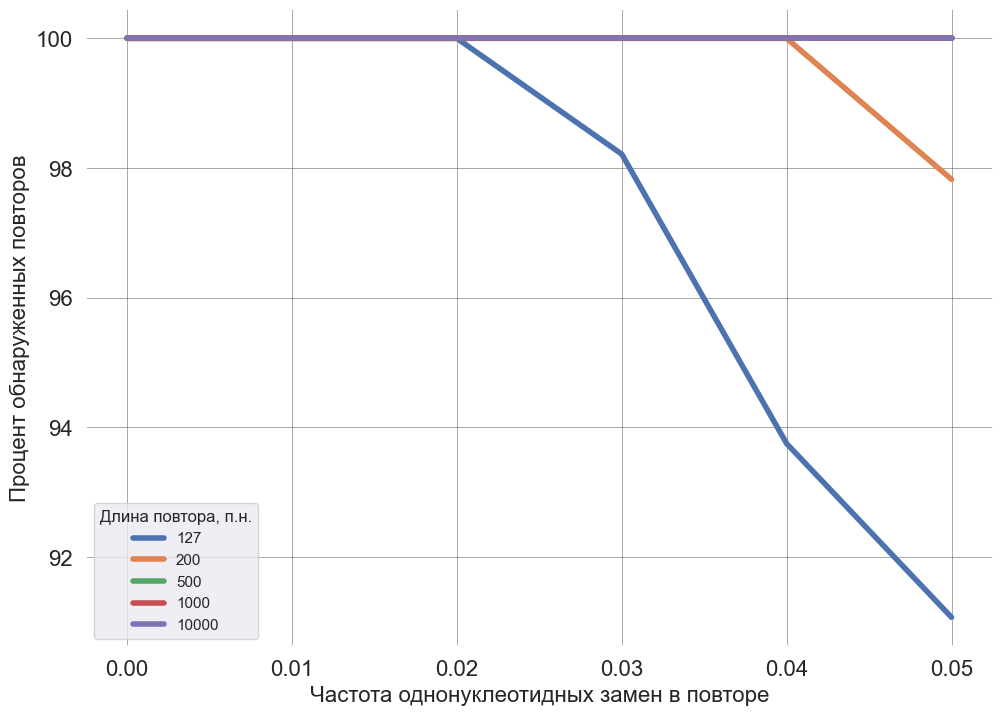

In [26]:
sns.set_theme(rc={'figure.figsize':(11.7,8.27)})

ax = sns.lineplot(
    all_summary_df,
    x='rate',
    y='repeat_detected_percent',
    hue='repeat_len',
    linewidth=4.0
)

ax.set_xlabel('Частота однонуклеотидных замен в повторе', fontsize=16)
ax.set_ylabel('Процент обнаруженных повторов', fontsize=16)

plt.legend(title='Длина повтора, п.н.')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

ax.grid(True, color='#505050', linestyle='-', linewidth=0.5, alpha=0.7)
ax.set_facecolor('#ffffff')

plt.show(ax)

# Make total coord diff plot

In [27]:
per_rate_len127_coord_diff_df = get_per_rate_coord_diff_df(
    repeat_detect_df,
    true_df,
    repeat_len=127
)
per_rate_len200_coord_diff_df = get_per_rate_coord_diff_df(
    repeat_detect_df,
    true_df,
    repeat_len=200
)
per_rate_len500_coord_diff_df = get_per_rate_coord_diff_df(
    repeat_detect_df,
    true_df,
    repeat_len=500
)
per_rate_len1k_coord_diff_df = get_per_rate_coord_diff_df(
    repeat_detect_df,
    true_df,
    repeat_len=1000
)
per_rate_len10k_coord_diff_df = get_per_rate_coord_diff_df(
    repeat_detect_df,
    true_df,
    repeat_len=10000
)

all_coord_df = pl.concat([
    per_rate_len127_coord_diff_df,
    per_rate_len200_coord_diff_df,
    per_rate_len500_coord_diff_df,
    per_rate_len1k_coord_diff_df,
    per_rate_len10k_coord_diff_df,
])
all_coord_df = all_coord_df.with_columns(
    pl.col('repeat_len').cast(pl.String)
)
all_coord_df.head()

chr,repeat_id,repeat_idx,rate,start_coord_diff,end_coord_diff,coord_diff_sum,repeat_len
str,str,i64,f64,i64,i64,i64,str
"""replicon_1""","""127_67_0.05_replicon_1""",67,0.05,81,16,97,"""127"""
"""replicon_2""","""127_88_0.04_replicon_2""",88,0.04,86,77,163,"""127"""
"""replicon_2""","""127_71_0.04_replicon_2""",71,0.04,46,1,47,"""127"""
"""replicon_2""","""127_5_0.0_replicon_2""",5,0.0,95,0,95,"""127"""
"""replicon_1""","""127_53_0.0_replicon_1""",53,0.0,98,0,98,"""127"""


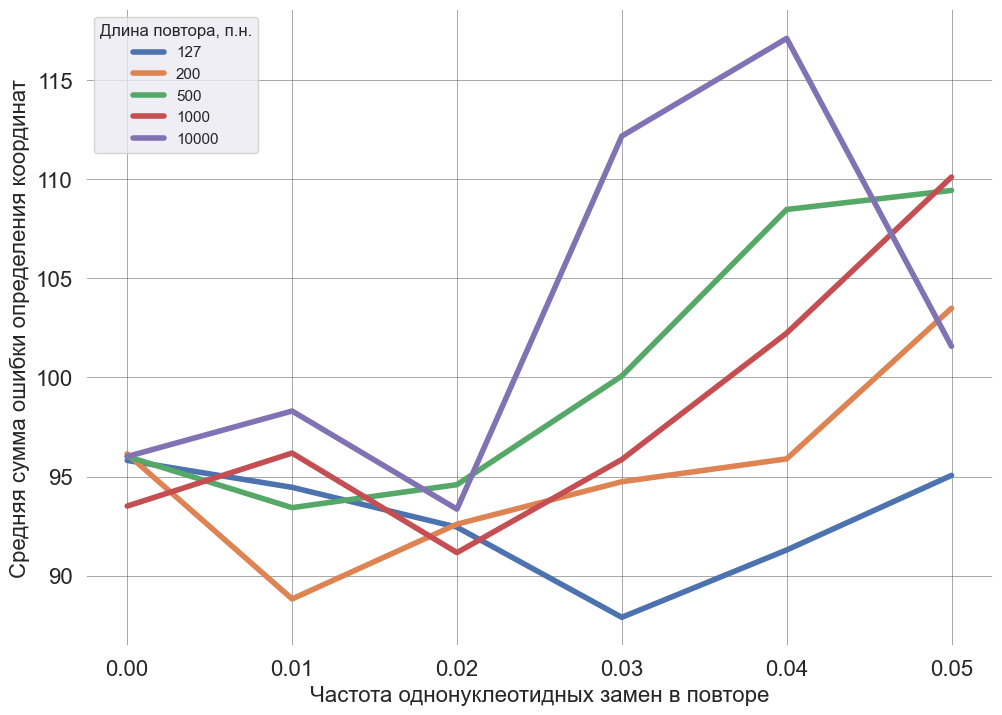

In [28]:
all_coord_mean_df = all_coord_df.group_by(['rate', 'repeat_len']) \
    .agg(pl.col('coord_diff_sum').mean().alias('mean_coord_diff_sum'))

sns.set_theme(rc={'figure.figsize':(11.7,8.27)})

ax = sns.lineplot(
    all_coord_mean_df,
    x='rate',
    y='mean_coord_diff_sum',
    hue='repeat_len',
    linewidth=4.0
)

ax.set_xlabel('Частота однонуклеотидных замен в повторе', fontsize=16)
ax.set_ylabel('Средняя сумма ошибки определения координат', fontsize=16)

plt.legend(title='Длина повтора, п.н.')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

ax.grid(True, color='#505050', linestyle='-', linewidth=0.5, alpha=0.7)
ax.set_facecolor('#ffffff')

plt.show(ax)

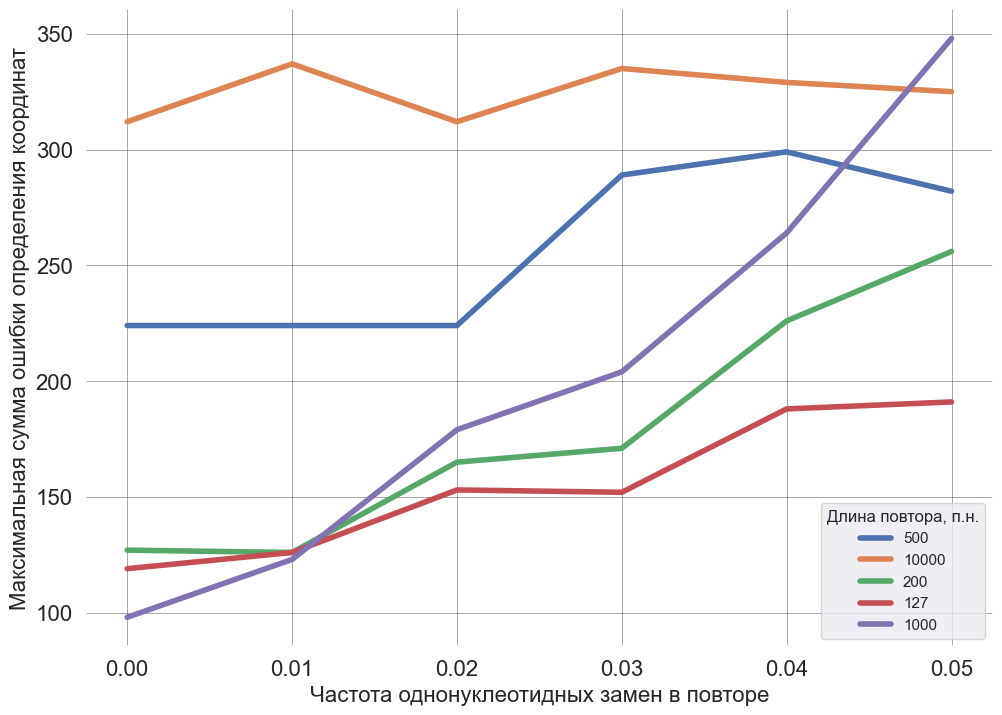

In [29]:
all_coord_mean_df = all_coord_df.group_by(['rate', 'repeat_len']) \
    .agg(pl.col('coord_diff_sum').max().alias('max_coord_diff_sum'))

sns.set_theme(rc={'figure.figsize':(11.7,8.27)})

ax = sns.lineplot(
    all_coord_mean_df,
    x='rate',
    y='max_coord_diff_sum',
    hue='repeat_len',
    linewidth=4.0
)

ax.set_xlabel('Частота однонуклеотидных замен в повторе', fontsize=16)
ax.set_ylabel('Максимальная сумма ошибки определения координат', fontsize=16)

plt.legend(title='Длина повтора, п.н.')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

ax.grid(True, color='#505050', linestyle='-', linewidth=0.5, alpha=0.7)
ax.set_facecolor('#ffffff')

plt.show(ax)